# E-Commerce Return Rate Reduction Analysis

**Objective:** Identify why customers return products and how return rates vary by category, geography, and customer segment; build a return-risk prediction model and export a Power BI-ready dataset with drill-through fields.

**Tools:** Python (pandas, seaborn, scikit-learn), SQL-style aggregation logic, Power BI

**Note on scope:** The dataset does not include a `Supplier` or `Marketing_Channel` field. Category (`Product_Category`) is used as the closest proxy for supplier-level analysis, and `User_Location` (100 city codes) is used as the geography dimension.

**Deliverables produced by this notebook:**
- Cleaned dataset with engineered features
- Return-rate breakdowns by category, geography, shipping, payment, age, discount, and time
- Logistic regression model predicting return probability
- `high_risk_products.csv` — high-risk product list
- `powerbi_dataset_scored.csv` — full dataset with risk scores for the Power BI dashboard


## Step 1: Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

DATA_PATH = "../Dataset/returns_sustainability_dataset.csv"  # dataset lives in a sibling Dataset folder
df = pd.read_csv(DATA_PATH)
df.head()

,Order_ID,Product_ID,User_ID,Order_Date,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,...,Return_Status,Return_Reason,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
0,ORD00000,PROD0169,USER0195,2022-01-14,Clothing,1720.71,2,30.46,Next-Day,Wallet,...,Not Returned,No Return,0,2393.163468,0,2393.163468,2.0,0.4,2.0,0.4
1,ORD00001,PROD0318,USER1469,2022-01-03,Toys,744.06,5,29.62,Next-Day,Wallet,...,Returned,Size Issue,12,2618.347140,200,2418.347140,2.0,1.0,0.0,0.0
2,ORD00002,PROD0427,USER1812,2025-03-16,Clothing,983.68,5,47.80,Express,Wallet,...,Not Returned,No Return,0,2567.404800,0,2567.404800,1.5,1.0,1.5,1.0
3,ORD00003,PROD0323,USER1274,2024-11-06,Books,1855.65,2,2.90,Express,COD,...,Not Returned,No Return,0,3603.672300,0,3603.672300,1.5,0.4,1.5,0.4
4,ORD00004,PROD0325,USER0551,2023-06-07,Home Appliances,1770.97,5,44.42,Express,COD,...,Returned,Size Issue,11,4921.525630,200,4721.525630,1.5,1.0,0.0,0.0


## Step 2: Understand the Data

In [2]:
df.shape

(5000, 23)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          5000 non-null   str    
 1   Product_ID        5000 non-null   str    
 2   User_ID           5000 non-null   str    
 3   Order_Date        5000 non-null   str    
 4   Product_Category  5000 non-null   str    
 5   Product_Price     5000 non-null   float64
 6   Order_Quantity    5000 non-null   int64  
 7   Discount_Applied  5000 non-null   float64
 8   Shipping_Method   5000 non-null   str    
 9   Payment_Method    5000 non-null   str    
 10  User_Age          5000 non-null   int64  
 11  User_Gender       5000 non-null   str    
 12  User_Location     5000 non-null   str    
 13  Return_Status     5000 non-null   str    
 14  Return_Reason     5000 non-null   str    
 15  Days_to_Return    5000 non-null   int64  
 16  Order_Value       5000 non-null   float64
 17  Return

In [4]:
df.describe()

,Product_Price,Order_Quantity,Discount_Applied,User_Age,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,1054.294740,2.997600,25.011476,41.551800,9.204200,2366.996469,58.000000,2308.996469,1.500100,0.599520,1.066600,0.42668
std,548.560406,1.400709,14.430681,13.890195,16.753156,1834.851991,90.761487,1838.461511,0.410346,0.280142,0.764448,0.36150
min,100.090000,1.000000,0.000000,18.000000,0.000000,52.165727,0.000000,-147.834273,1.000000,0.200000,0.000000,0.00000
25%,580.937500,2.000000,12.827500,30.000000,0.000000,928.078449,0.000000,863.905130,1.000000,0.400000,0.000000,0.00000
50%,1044.850000,3.000000,25.020000,42.000000,0.000000,1864.584054,0.000000,1808.077845,1.500000,0.600000,1.000000,0.40000
75%,1530.835000,4.000000,37.380000,54.000000,12.000000,3382.309799,200.000000,3345.675860,2.000000,0.800000,1.500000,0.80000
max,1999.800000,5.000000,50.000000,65.000000,60.000000,9827.017200,200.000000,9827.017200,2.000000,1.000000,2.000000,1.00000


In [5]:
for col in ['Return_Status','Return_Reason','Product_Category','Shipping_Method','Payment_Method']:
    print(f"--- {col} ---")
    print(df[col].value_counts(), "\n")

--- Return_Status ---
Return_Status
Not Returned    3550
Returned        1450
Name: count, dtype: int64 

--- Return_Reason ---
Return_Reason
No Return       3550
Defective        382
Changed Mind     379
Wrong Item       348
Size Issue       341
Name: count, dtype: int64 

--- Product_Category ---
Product_Category
Clothing           1766
Electronics        1244
Books               762
Toys                752
Home Appliances     476
Name: count, dtype: int64 

--- Shipping_Method ---
Shipping_Method
Next-Day    1684
Standard    1683
Express     1633
Name: count, dtype: int64 

--- Payment_Method ---
Payment_Method
Debit Card     1277
Wallet         1275
Credit Card    1235
COD            1213
Name: count, dtype: int64 



## Step 3: Data Quality Check

In [6]:
print("Nulls per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate Order_IDs:", df['Order_ID'].duplicated().sum())

Nulls per column:
 Order_ID            0
Product_ID          0
User_ID             0
Order_Date          0
Product_Category    0
Product_Price       0
Order_Quantity      0
Discount_Applied    0
Shipping_Method     0
Payment_Method      0
User_Age            0
User_Gender         0
User_Location       0
Return_Status       0
Return_Reason       0
Days_to_Return      0
Order_Value         0
Return_Cost         0
Profit_Loss         0
CO2_Emissions       0
Packaging_Waste     0
CO2_Saved           0
Waste_Avoided       0
dtype: int64

Duplicate rows: 0
Duplicate Order_IDs: 0


**Result:** No missing values, no duplicate rows, no duplicate order IDs — the dataset is already clean at the row level.

## Step 4: Convert Dates & Engineer Features

In [7]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Return_Flag'] = np.where(df['Return_Status'] == 'Returned', 1, 0)
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.month_name()
df['Year_Month'] = df['Order_Date'].dt.to_period('M').astype(str)

bins_age = [0, 18, 25, 35, 45, 55, 65, 100]
labels_age = ["Under 18","18-25","26-35","36-45","46-55","56-65","65+"]
df['Age_Group'] = pd.cut(df['User_Age'], bins=bins_age, labels=labels_age)

df['Discount_Group'] = pd.cut(df['Discount_Applied'], bins=[-1,10,20,30,40,50],
    labels=["0-10%","11-20%","21-30%","31-40%","41-50%"])

df.head()

,Order_ID,Product_ID,User_ID,Order_Date,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,...,Packaging_Waste,CO2_Saved,Waste_Avoided,Return_Flag,Year,Month,Month_Name,Year_Month,Age_Group,Discount_Group
0,ORD00000,PROD0169,USER0195,2022-01-14,Clothing,1720.71,2,30.46,Next-Day,Wallet,...,0.4,2.0,0.4,0,2022,1,January,2022-01,56-65,31-40%
1,ORD00001,PROD0318,USER1469,2022-01-03,Toys,744.06,5,29.62,Next-Day,Wallet,...,1.0,0.0,0.0,1,2022,1,January,2022-01,46-55,21-30%
2,ORD00002,PROD0427,USER1812,2025-03-16,Clothing,983.68,5,47.80,Express,Wallet,...,1.0,1.5,1.0,0,2025,3,March,2025-03,36-45,41-50%
3,ORD00003,PROD0323,USER1274,2024-11-06,Books,1855.65,2,2.90,Express,COD,...,0.4,1.5,0.4,0,2024,11,November,2024-11,46-55,0-10%
4,ORD00004,PROD0325,USER0551,2023-06-07,Home Appliances,1770.97,5,44.42,Express,COD,...,1.0,0.0,0.0,1,2023,6,June,2023-06,26-35,41-50%


## Step 5: Overall Return Rate

In [8]:
total_orders = df['Order_ID'].nunique()
returned_orders = df.loc[df['Return_Status']=='Returned','Order_ID'].nunique()
return_rate = returned_orders/total_orders*100

print("Total Orders:", total_orders)
print("Returned Orders:", returned_orders)
print("Return Rate:", round(return_rate,2), "%")

Total Orders: 5000
Returned Orders: 1450
Return Rate: 29.0 %


**~29% of all orders are returned** — a high rate that justifies a dedicated reduction initiative.

## Step 6: Return Reasons

Return_Reason
Defective       382
Changed Mind    379
Wrong Item      348
Size Issue      341
Name: count, dtype: int64


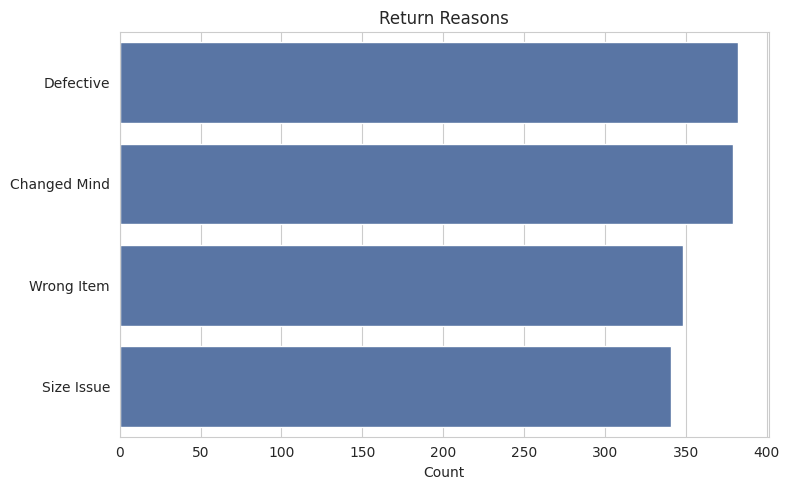

In [9]:
reasons = df[df['Return_Status']=='Returned']['Return_Reason'].value_counts()
print(reasons)

plt.figure(figsize=(8,5))
sns.countplot(data=df[df['Return_Status']=='Returned'], y='Return_Reason', order=reasons.index, color='#4C72B0')
plt.title('Return Reasons'); plt.xlabel('Count'); plt.ylabel('')
plt.tight_layout(); plt.show()

**Defective items (26%)** and **changed mind (26%)** are the top two reasons, followed closely by wrong item and size issues — a near-even split suggests both quality-control and product-description/sizing issues need attention.

## Step 7: Return Rate by Product Category

In [10]:
category_analysis = df.groupby('Product_Category').agg(
    Total_Orders=('Order_ID','nunique'),
    Returned_Orders=('Return_Flag','sum'),
    Revenue=('Order_Value','sum'),
    Return_Cost=('Return_Cost','sum')
).reset_index()
category_analysis['Return_Rate'] = category_analysis['Returned_Orders']/category_analysis['Total_Orders']*100
category_analysis = category_analysis.sort_values('Return_Rate', ascending=False)
category_analysis

,Product_Category,Total_Orders,Returned_Orders,Revenue,Return_Cost,Return_Rate
1,Clothing,1766,661,4.170020e+06,132200,37.429219
3,Home Appliances,476,122,1.151587e+06,24400,25.630252
2,Electronics,1244,314,2.908236e+06,62800,25.241158
4,Toys,752,181,1.854903e+06,36200,24.069149
0,Books,762,172,1.750236e+06,34400,22.572178


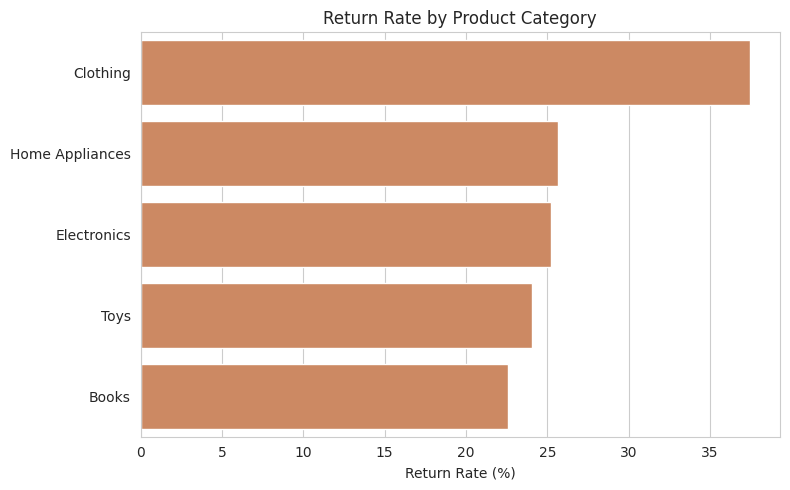

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(data=category_analysis, x='Return_Rate', y='Product_Category', color='#DD8452')
plt.title('Return Rate by Product Category'); plt.xlabel('Return Rate (%)'); plt.ylabel('')
plt.tight_layout(); plt.show()

**Clothing has the highest return rate at 37.4%** — well above the 25% overall average of the other four categories — driven likely by sizing/fit issues. This is the single highest-leverage category to target first.

## Step 8: Return Rate by Geography (User Location)

In [12]:
geo = df.groupby('User_Location').agg(Total_Orders=('Order_ID','nunique'), Returned=('Return_Flag','sum')).reset_index()
geo = geo[geo['Total_Orders'] >= 20]   # filter for statistical reliability
geo['Return_Rate'] = geo['Returned']/geo['Total_Orders']*100

print("Highest return-rate locations:")
print(geo.sort_values('Return_Rate', ascending=False).head(10))
print("\nLowest return-rate locations:")
print(geo.sort_values('Return_Rate', ascending=True).head(10))

Highest return-rate locations:
   User_Location  Total_Orders  Returned  Return_Rate
39        City44            38        19    50.000000
84        City85            41        18    43.902439
75        City77            44        19    43.181818
51        City55            50        21    42.000000
54        City58            50        21    42.000000
45         City5            48        20    41.666667
52        City56            30        12    40.000000
90        City90            53        21    39.622642
13        City20            62        24    38.709677
59        City62            52        20    38.461538

Lowest return-rate locations:
   User_Location  Total_Orders  Returned  Return_Rate
46        City50            51         7    13.725490
77        City79            48         7    14.583333
63        City66            58         9    15.517241
82        City83            45         7    15.555556
31        City37            65        12    18.461538
17        City24    

Return rate varies from **~14% to ~50%** across locations with sufficient order volume — a 3.5x spread. This points to regional factors (courier quality, delivery damage, local product-fit expectations) worth investigating with the logistics/regional teams.

## Step 9: Return Rate by Shipping Method

In [13]:
shipping_analysis = df.groupby('Shipping_Method').agg(Total_Orders=('Order_ID','nunique'), Returned=('Return_Flag','sum')).reset_index()
shipping_analysis['Return_Rate'] = shipping_analysis['Returned']/shipping_analysis['Total_Orders']*100
shipping_analysis

,Shipping_Method,Total_Orders,Returned,Return_Rate
0,Express,1633,475,29.087569
1,Next-Day,1684,480,28.503563
2,Standard,1683,495,29.411765


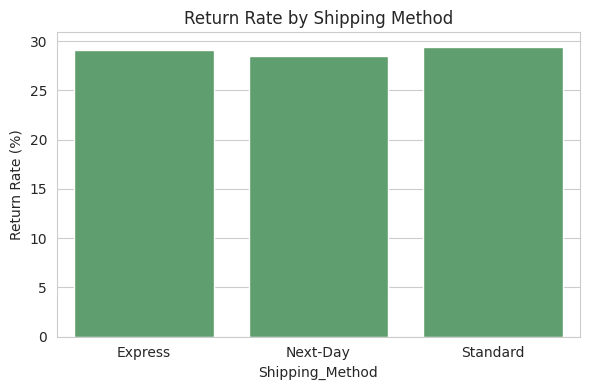

In [14]:
plt.figure(figsize=(6,4))
sns.barplot(data=shipping_analysis, x='Shipping_Method', y='Return_Rate', color='#55A868')
plt.title('Return Rate by Shipping Method'); plt.ylabel('Return Rate (%)')
plt.tight_layout(); plt.show()

Shipping method shows **almost no difference** (28.5%–29.4%) — this is not a meaningful lever for return reduction.

## Step 10: Return Rate by Payment Method

In [15]:
payment_analysis = df.groupby('Payment_Method').agg(Total_Orders=('Order_ID','nunique'), Returned=('Return_Flag','sum')).reset_index()
payment_analysis['Return_Rate'] = payment_analysis['Returned']/payment_analysis['Total_Orders']*100
payment_analysis

,Payment_Method,Total_Orders,Returned,Return_Rate
0,COD,1213,370,30.502885
1,Credit Card,1235,383,31.012146
2,Debit Card,1277,351,27.486296
3,Wallet,1275,346,27.137255


Credit Card (31.0%) and COD (30.5%) run slightly higher than Debit Card/Wallet (~27%) — a modest but consistent gap, possibly tied to lower purchase-commitment for non-prepaid or 'buy now, decide later' payment types.

## Step 11: Customer Age Analysis

In [16]:
age_analysis = df.groupby('Age_Group', observed=True).agg(Total_Orders=('Order_ID','nunique'), Returned=('Return_Flag','sum')).reset_index()
age_analysis['Return_Rate'] = age_analysis['Returned']/age_analysis['Total_Orders']*100
age_analysis

,Age_Group,Total_Orders,Returned,Return_Rate
0,Under 18,106,24,22.641509
1,18-25,739,222,30.040595
2,26-35,1025,302,29.463415
3,36-45,1048,311,29.675573
4,46-55,1032,284,27.519380
5,56-65,1050,307,29.238095


Return rate is fairly flat across adult age bands (27–30%); Under-18 is lower (22.6%) but represents a small sample (106 orders).

## Step 12: Discount vs Return Rate

In [17]:
discount_analysis = df.groupby('Discount_Group', observed=True).agg(Total_Orders=('Order_ID','nunique'), Returned=('Return_Flag','sum')).reset_index()
discount_analysis['Return_Rate'] = discount_analysis['Returned']/discount_analysis['Total_Orders']*100
discount_analysis

,Discount_Group,Total_Orders,Returned,Return_Rate
0,0-10%,977,235,24.053224
1,11-20%,1005,270,26.865672
2,21-30%,1054,273,25.901328
3,31-40%,943,332,35.206787
4,41-50%,1021,340,33.300686


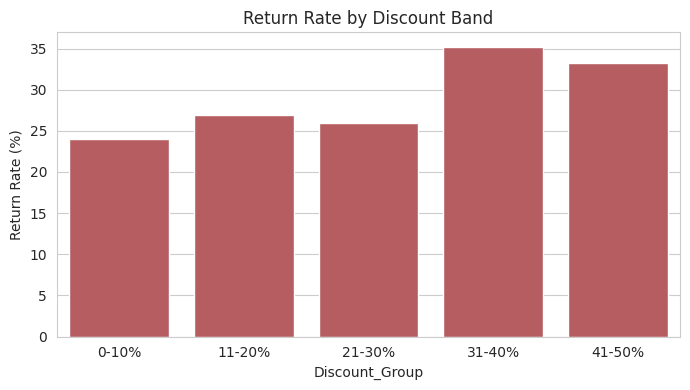

In [18]:
plt.figure(figsize=(7,4))
sns.barplot(data=discount_analysis, x='Discount_Group', y='Return_Rate', color='#C44E52')
plt.title('Return Rate by Discount Band'); plt.ylabel('Return Rate (%)')
plt.tight_layout(); plt.show()

**Clear upward trend:** return rate climbs from 24% at 0–10% discount to 33–35% at 31–50% discount. Deep discounting appears to attract lower-commitment purchases — a strong, actionable signal for pricing/promo strategy.

## Step 13: Monthly Return Rate Trend

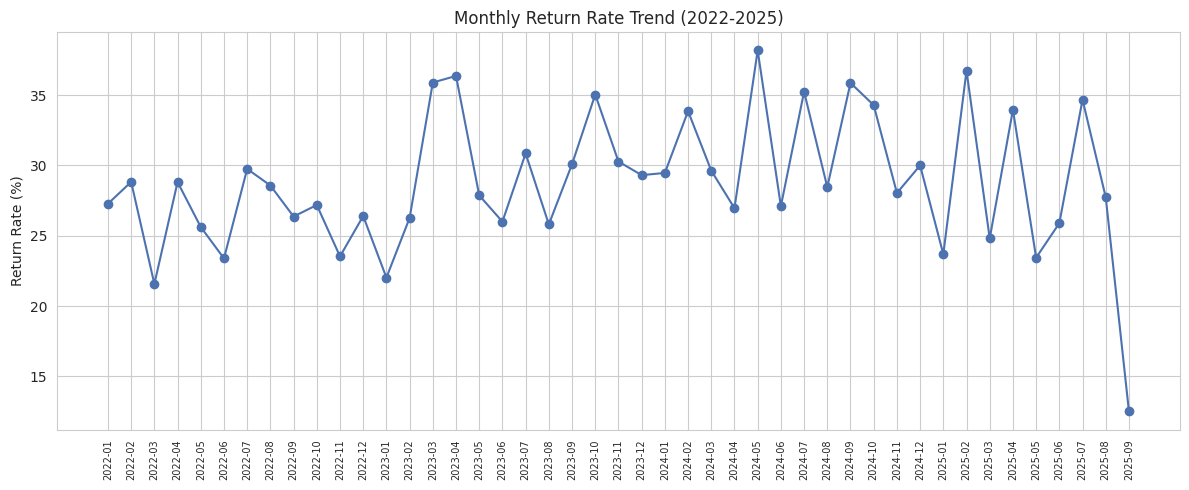

In [19]:
trend = df.groupby('Year_Month').agg(Total_Orders=('Order_ID','nunique'), Returned=('Return_Flag','sum')).reset_index()
trend['Return_Rate'] = trend['Returned']/trend['Total_Orders']*100

plt.figure(figsize=(12,5))
plt.plot(trend['Year_Month'], trend['Return_Rate'], marker='o', color='#4C72B0')
plt.xticks(rotation=90, fontsize=7)
plt.title('Monthly Return Rate Trend (2022-2025)'); plt.ylabel('Return Rate (%)')
plt.tight_layout(); plt.show()

## Step 14: Return Cost & Profit/Loss Impact

In [20]:
returned_df = df[df['Return_Status']=='Returned']
total_return_cost = returned_df['Return_Cost'].sum()
average_return_cost = returned_df['Return_Cost'].mean()
print("Total Return Cost:", total_return_cost)
print("Average Return Cost per Return:", round(average_return_cost,2))

Total Return Cost: 290000
Average Return Cost per Return: 200.0


In [21]:
pl = df.groupby('Return_Status')['Profit_Loss'].agg(['sum','mean'])
pl

,sum,mean
Return_Status,,
Not Returned,8.465591e+06,2384.673387
Returned,3.079392e+06,2123.718499


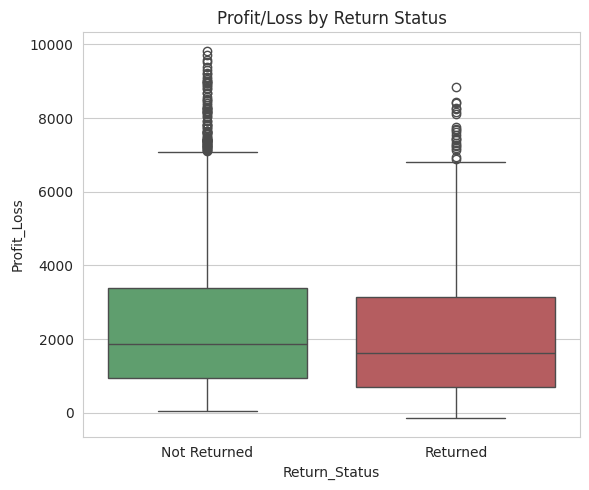

In [22]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='Return_Status', y='Profit_Loss', hue='Return_Status', palette=['#55A868','#C44E52'], legend=False)
plt.title('Profit/Loss by Return Status')
plt.tight_layout(); plt.show()

Returns cost the business **₹2.9 lakh (₹290,000) total** at an average of ₹200/return, and returned orders average ~11% lower profit per order than kept orders.

## Step 15: Sustainability Impact

In [23]:
sustainability = df.groupby('Return_Status').agg(
    CO2_Emissions=('CO2_Emissions','sum'),
    Packaging_Waste=('Packaging_Waste','sum'),
    CO2_Saved=('CO2_Saved','sum'),
    Waste_Avoided=('Waste_Avoided','sum')
).reset_index()
sustainability

,Return_Status,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
0,Not Returned,5333.0,2133.4,5333.0,2133.4
1,Returned,2167.5,864.2,0.0,0.0


Returned orders generate additional CO2 emissions and packaging waste from reverse logistics with **zero offsetting savings** — every return is a pure environmental cost on top of its financial cost, reinforcing the case for return prevention over return handling.

## Step 16: Logistic Regression — Predicting Return Probability

We build a classification model to estimate each order's probability of being returned, using only features known **at the time of purchase** (excluding return reason, days-to-return, return cost, profit/loss, and sustainability fields, which are only known *after* a return happens and would leak the outcome).

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report)

cat_features = ['Product_Category','Shipping_Method','Payment_Method','User_Gender','Age_Group']
num_features = ['Product_Price','Order_Quantity','Discount_Applied','User_Age','Order_Value']

X = pd.get_dummies(df[cat_features + num_features], columns=cat_features, drop_first=True)
y = df['Return_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:,1]

print("Accuracy:", round(accuracy_score(y_test,y_pred),3))
print("Precision:", round(precision_score(y_test,y_pred),3))
print("Recall:", round(recall_score(y_test,y_pred),3))
print("F1 Score:", round(f1_score(y_test,y_pred),3))
print("ROC AUC:", round(roc_auc_score(y_test,y_proba),3))
print("\n", classification_report(y_test,y_pred))

Accuracy: 0.585
Precision: 0.355
Recall: 0.528
F1 Score: 0.424
ROC AUC: 0.596

               precision    recall  f1-score   support

           0       0.76      0.61      0.68       710
           1       0.35      0.53      0.42       290

    accuracy                           0.58      1000
   macro avg       0.56      0.57      0.55      1000
weighted avg       0.64      0.58      0.60      1000



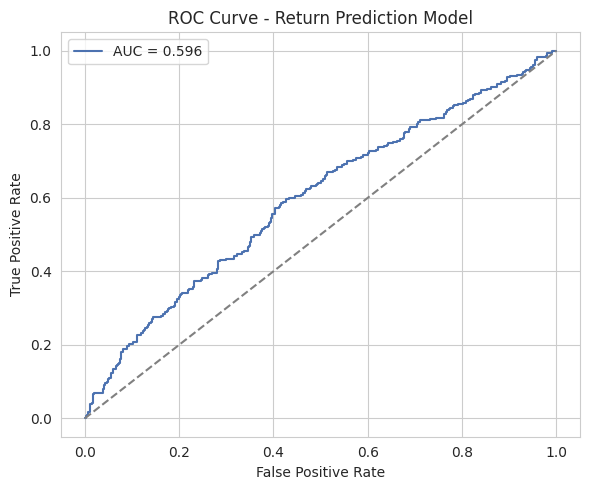

In [25]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test,y_proba):.3f}', color='#4C72B0')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Return Prediction Model')
plt.legend(); plt.tight_layout(); plt.show()

**Model performance note:** ROC AUC of ~0.60 indicates the pre-purchase fields in this dataset (category, price, discount, shipping, payment, demographics) carry only a **weak-to-moderate** signal for predicting returns — real-world return prediction usually needs richer features (return history per customer, product review/rating data, size-chart deviation, image-vs-received mismatches). Treat this model as a *first-pass risk-ranking tool*, not a high-precision classifier — it's still useful for prioritizing which products/orders to review, just don't oversell its accuracy in the portfolio writeup.

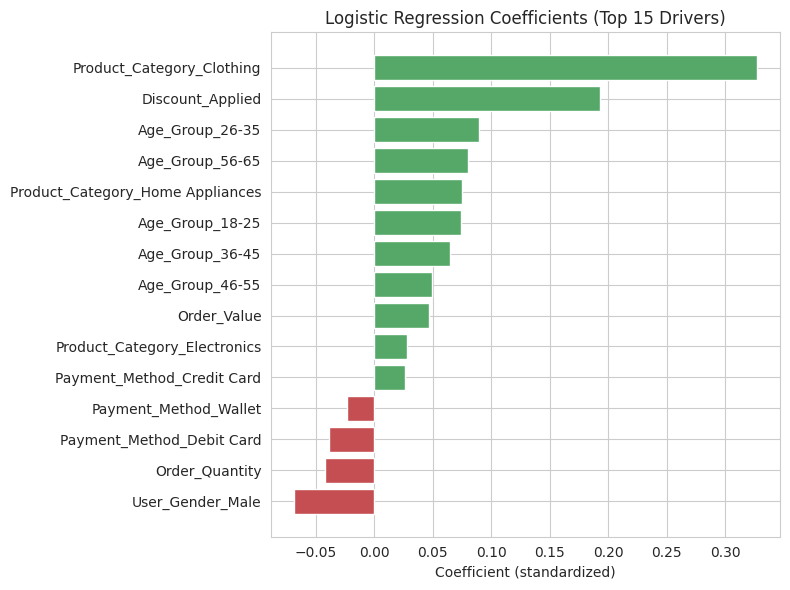

,Feature,Coefficient
5,Product_Category_Clothing,0.326883
2,Discount_Applied,0.192853
16,Age_Group_26-35,0.089865
19,Age_Group_56-65,0.079845
7,Product_Category_Home Appliances,0.074611
15,Age_Group_18-25,0.073904
14,User_Gender_Male,-0.068263
17,Age_Group_36-45,0.064668
18,Age_Group_46-55,0.049475
4,Order_Value,0.046437


In [26]:
coefs = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefs['Abs_Coef'] = coefs['Coefficient'].abs()
coefs = coefs.sort_values('Abs_Coef', ascending=False)

plt.figure(figsize=(8,6))
top15 = coefs.head(15).sort_values('Coefficient')
colors = ['#C44E52' if c<0 else '#55A868' for c in top15['Coefficient']]
plt.barh(top15['Feature'], top15['Coefficient'], color=colors)
plt.title('Logistic Regression Coefficients (Top 15 Drivers)')
plt.xlabel('Coefficient (standardized)')
plt.tight_layout(); plt.show()

coefs.head(10)[['Feature','Coefficient']]

The strongest positive drivers of return probability are **Clothing category** and **Discount_Applied** — consistent with the EDA findings above. This cross-validation between the descriptive stats and the model coefficients is a good sign the signal is real, even if modest.

## Step 17: Score All Orders & Products for Risk

In [27]:
X_full_s = scaler.transform(X)
df['Return_Risk_Score'] = model.predict_proba(X_full_s)[:,1]

def risk_band(p):
    if p >= 0.7: return 'High'
    elif p >= 0.4: return 'Medium'
    else: return 'Low'

df['Risk_Band'] = df['Return_Risk_Score'].apply(risk_band)
df['Risk_Band'].value_counts()

Risk_Band
Medium    4116
Low        875
High         9
Name: count, dtype: int64

In [28]:
product_risk = df.groupby('Product_ID').agg(
    Product_Category=('Product_Category','first'),
    Orders=('Order_ID','nunique'),
    Actual_Returns=('Return_Flag','sum'),
    Avg_Risk_Score=('Return_Risk_Score','mean')
).reset_index()
product_risk['Actual_Return_Rate_%'] = (product_risk['Actual_Returns']/product_risk['Orders']*100).round(2)
product_risk['Avg_Risk_Score'] = product_risk['Avg_Risk_Score'].round(3)
product_risk = product_risk.sort_values('Avg_Risk_Score', ascending=False)

high_risk_products = product_risk[product_risk['Avg_Risk_Score'] >= 0.5]
print(f"High-risk products (avg score >= 0.5): {len(high_risk_products)} of {len(product_risk)}")
high_risk_products.head(15)

High-risk products (avg score >= 0.5): 201 of 500


,Product_ID,Product_Category,Orders,Actual_Returns,Avg_Risk_Score,Actual_Return_Rate_%
496,PROD0497,Clothing,6,1,0.589,16.67
37,PROD0038,Clothing,3,2,0.584,66.67
362,PROD0363,Clothing,3,1,0.574,33.33
376,PROD0377,Clothing,10,3,0.571,30.00
324,PROD0325,Home Appliances,5,2,0.568,40.00
284,PROD0285,Clothing,9,5,0.564,55.56
31,PROD0032,Toys,10,3,0.563,30.00
431,PROD0432,Home Appliances,13,4,0.560,30.77
106,PROD0107,Clothing,6,2,0.559,33.33
306,PROD0307,Clothing,8,4,0.556,50.00


## Step 18: Export Deliverables

In [29]:
product_risk.to_csv('all_products_risk_scored.csv', index=False)
high_risk_products.to_csv('high_risk_products.csv', index=False)

powerbi_cols = ['Order_ID','Product_ID','User_ID','Order_Date','Product_Category','Product_Price',
    'Order_Quantity','Discount_Applied','Shipping_Method','Payment_Method','User_Age','User_Gender',
    'User_Location','Age_Group','Discount_Group','Return_Status','Return_Reason','Days_to_Return',
    'Order_Value','Return_Cost','Profit_Loss','CO2_Emissions','Packaging_Waste','CO2_Saved',
    'Waste_Avoided','Year','Month','Month_Name','Year_Month','Return_Flag','Return_Risk_Score','Risk_Band']
df[powerbi_cols].to_csv('powerbi_dataset_scored.csv', index=False)

print("Saved: all_products_risk_scored.csv, high_risk_products.csv, powerbi_dataset_scored.csv")

Saved: all_products_risk_scored.csv, high_risk_products.csv, powerbi_dataset_scored.csv


## Conclusion & Key Insights

1. **Overall return rate is 29%** — high enough to represent a material cost and sustainability drag.
2. **Clothing drives the most returns (37.4%)**, well above other categories — start reduction efforts here (better size guides, size-recommendation tools, clearer product photos).
3. **Discounting is strongly linked to returns** — orders with 31–50% discount return at 33–35% vs. 24% at 0–10% discount. Reassess deep-discount promotions or add stricter return windows for heavily discounted items.
4. **Geography matters a lot** (14%–50% return rate range across cities) — worth a regional deep-dive with logistics/fulfillment teams for the worst-performing locations.
5. **Return reasons split almost evenly** between Defective, Changed Mind, Wrong Item, and Size Issue — meaning both quality control *and* customer-expectation-setting (photos, sizing, descriptions) need attention; no single fix will move the needle alone.
6. **Shipping method and payment method are weak levers** — small return-rate differences, not worth prioritizing.
7. **Every return is a pure sustainability cost** — no CO2/waste is offset when an order is returned, strengthening the business case for prevention over handling.
8. **The logistic regression model (AUC ≈ 0.60) is a directional risk-ranking tool**, not a precise classifier — useful to flag ~40% of products as elevated-risk for manual review, but its main value here is confirming the category/discount findings independently.

### Recommended next steps for the Power BI dashboard
- **Page 1 – Executive Overview:** overall return rate, cost, trend line, KPI cards
- **Page 2 – Root Cause Analysis:** return reasons, category and geography breakdowns
- **Page 3 – Risk & Prediction:** risk score distribution, high-risk product table with drill-through to order level
- **Page 4 – Financial & Sustainability Impact:** return cost, profit/loss, CO2/waste comparison
